# MSCS 634 – Lab Assignment 5

**Name:** Oishani Ganguly  
**Course Title:** MSCS-634: Advanced Big Data and Data Mining  
**Lab Assignment Title:** Lab 5: Clustering Techniques Using DBSCAN and Hierarchical Clustering  

---

## Dataset: Wine Dataset (sklearn)
Source: `sklearn.datasets.load_wine()`  
The Wine dataset contains 178 samples representing three cultivars of Italian wine, each described by 13 continuous chemical features (e.g., alcohol content, malic acid, flavanoids, color intensity). Unlike the supervised classification tasks in Lab 2, here we treat the class labels as **ground-truth evaluation references only** — the clustering algorithms receive no label information and must discover structure from the feature space alone. This setup allows us to evaluate whether the chemical profiles of wines form naturally separable groups without any prior knowledge of cultivar identity.

---
## Step 1: Data Preparation and Exploration

We begin by importing all required libraries, loading the Wine dataset, and converting it to a Pandas DataFrame for inspection. We examine the dataset's structure using `.head()`, `.info()`, and `.describe()`, check for missing values, and then apply **StandardScaler** to normalize the features.

Standardization is especially critical for clustering algorithms because both Hierarchical Clustering and DBSCAN rely on Euclidean distance. Without it, features with large absolute values (e.g., `proline`, which ranges in the hundreds) would completely dominate the distance calculations, effectively rendering the other 12 features invisible to the algorithm.

In [81]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [82]:
# Load the Wine dataset
wine = load_wine()

# Build a DataFrame for exploration
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['true_label'] = wine.target  # stored for evaluation only — NOT passed to clustering

print(f'Dataset shape   : {df.shape[0]} rows × {len(wine.feature_names)} features')
print(f'Features ({len(wine.feature_names)})  : {wine.feature_names}')
print(f'True classes    : {list(wine.target_names)}')
print(f'Class counts    : {dict(zip(*np.unique(wine.target, return_counts=True)))}')

Dataset shape   : 178 rows × 13 features
Features (13)  : ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
True classes    : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]
Class counts    : {np.int64(0): np.int64(59), np.int64(1): np.int64(71), np.int64(2): np.int64(48)}


In [83]:
# Preview the first few rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,true_label
0,14.2300,1.7100,2.4300,15.6000,127.0000,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,1065.0000,0
1,13.2000,1.7800,2.1400,11.2000,100.0000,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,1050.0000,0
2,13.1600,2.3600,2.6700,18.6000,101.0000,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,1185.0000,0
3,14.3700,1.9500,2.5000,16.8000,113.0000,3.8500,3.4900,0.2400,2.1800,7.8000,0.8600,3.4500,1480.0000,0
4,13.2400,2.5900,2.8700,21.0000,118.0000,2.8000,2.6900,0.3900,1.8200,4.3200,1.0400,2.9300,735.0000,0


In [84]:
# Data types and null check
print('Dataset Info:')
df.info()
print()
print('Missing values per column:')
print(df.isnull().sum().to_string())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    floa

In [85]:
# Summary statistics (features only)
df[wine.feature_names].describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000
mean,13.0006,2.3363,2.3665,19.4949,99.7416,2.2951,2.0293,0.3619,1.5909,5.0581,0.9574,2.6117,746.8933
std,0.8118,1.1171,0.2743,3.3396,14.2825,0.6259,0.9989,0.1245,0.5724,2.3183,0.2286,0.7100,314.9075
min,11.0300,0.7400,1.3600,10.6000,70.0000,0.9800,0.3400,0.1300,0.4100,1.2800,0.4800,1.2700,278.0000
25%,12.3625,1.6025,2.2100,17.2000,88.0000,1.7425,1.2050,0.2700,1.2500,3.2200,0.7825,1.9375,500.5000
50%,13.0500,1.8650,2.3600,19.5000,98.0000,2.3550,2.1350,0.3400,1.5550,4.6900,0.9650,2.7800,673.5000
75%,13.6775,3.0825,2.5575,21.5000,107.0000,2.8000,2.8750,0.4375,1.9500,6.2000,1.1200,3.1700,985.0000
max,14.8300,5.8000,3.2300,30.0000,162.0000,3.8800,5.0800,0.6600,3.5800,13.0000,1.7100,4.0000,1680.0000


In [86]:
# Standardize features — fit on the full dataset (unsupervised; no train/test split needed)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(wine.data)
y_true   = wine.target   # ground-truth labels — used ONLY for evaluation metrics

print('Feature means after scaling (should all be ~0):')
print(np.round(X_scaled.mean(axis=0), 4))
print()
print('Feature std devs after scaling (should all be ~1):')
print(np.round(X_scaled.std(axis=0), 4))

Feature means after scaling (should all be ~0):
[ 0.  0. -0. -0. -0. -0.  0. -0. -0. -0.  0.  0. -0.]

Feature std devs after scaling (should all be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [87]:
# Compute PCA projection (2D) for all scatter plots
# PCA is used purely for visualization — clustering runs on all 13 standardized features
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_
print(f'PCA variance explained: PC1={var_explained[0]*100:.1f}%,'
      f' PC2={var_explained[1]*100:.1f}%'
      f' (total={sum(var_explained)*100:.1f}%)')

PCA variance explained: PC1=36.2%, PC2=19.2% (total=55.4%)


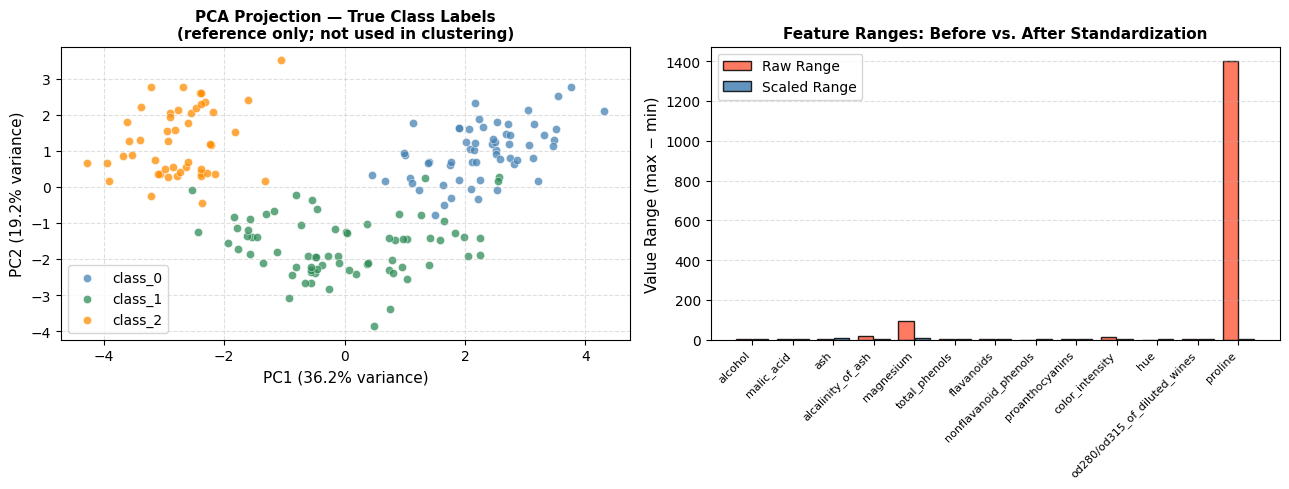

In [88]:
# Exploration plot: PCA scatter colored by true class + feature scale comparison
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- PCA scatter: true class labels ---
colors_true = ['steelblue', 'seagreen', 'darkorange']
for cls, color, name in zip([0, 1, 2], colors_true, wine.target_names):
    mask = y_true == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=35, alpha=0.75, color=color, label=name, edgecolors='white',
                    linewidths=0.4)
axes[0].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)', fontsize=11)
axes[0].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)', fontsize=11)
axes[0].set_title('PCA Projection — True Class Labels\n(reference only; not used in clustering)',
                   fontsize=11, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.4)

# --- Feature range before vs. after scaling ---
feature_ranges_raw    = wine.data.max(axis=0) - wine.data.min(axis=0)
feature_ranges_scaled = X_scaled.max(axis=0) - X_scaled.min(axis=0)
x_pos = np.arange(len(wine.feature_names))

axes[1].bar(x_pos - 0.2, feature_ranges_raw,    0.38, label='Raw Range',    color='tomato',
            edgecolor='black', alpha=0.85)
axes[1].bar(x_pos + 0.2, feature_ranges_scaled, 0.38, label='Scaled Range', color='steelblue',
            edgecolor='black', alpha=0.85)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(wine.feature_names, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('Value Range (max − min)', fontsize=11)
axes[1].set_title('Feature Ranges: Before vs. After Standardization', fontsize=11,
                   fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

**Observations – Data Preparation:**
- The Wine dataset is **complete** — no missing values are present, and all features are continuous numeric types requiring no encoding.
- The raw feature ranges vary enormously: `proline` spans over 1,000 units while `nonflavanoid_phenols` spans less than 1. Without standardization, any distance-based clustering algorithm would effectively cluster on `proline` alone.
- After standardization, all features have a range of approximately 3–5 units, ensuring equal contribution to distance calculations.
- The PCA projection (shown for reference) suggests the three wine cultivars form meaningful clusters in the feature space, giving us reason to believe unsupervised algorithms can discover this structure. The goal is not to replicate these labels but to find natural groupings — which may or may not align perfectly with cultivar boundaries.
- All clustering algorithms will receive only the **13 standardized features** (`X_scaled`). The `y_true` labels are reserved exclusively for post-hoc evaluation using Homogeneity and Completeness scores.

---
## Step 2: Hierarchical Clustering

**Agglomerative Hierarchical Clustering** builds a tree of clusters bottom-up: it starts with each sample as its own cluster and iteratively merges the two closest clusters until a single root cluster remains. The **dendrogram** captures the full merge history, and cutting the tree at a chosen height produces a flat partition into *n* clusters.

Key choices:
- **Linkage criterion:** We use `ward` linkage, which minimizes the total within-cluster variance at each merge step. Ward tends to produce compact, roughly equal-sized clusters and is generally the most robust choice for well-scaled data.
- **n_clusters:** We test n ∈ {2, 3, 4, 5} to observe how cluster granularity changes and identify which value best aligns with the natural structure of the data.

We generate the dendrogram using `scipy.cluster.hierarchy` for a full tree view, then use sklearn's `AgglomerativeClustering` to assign labels for each tested partition.

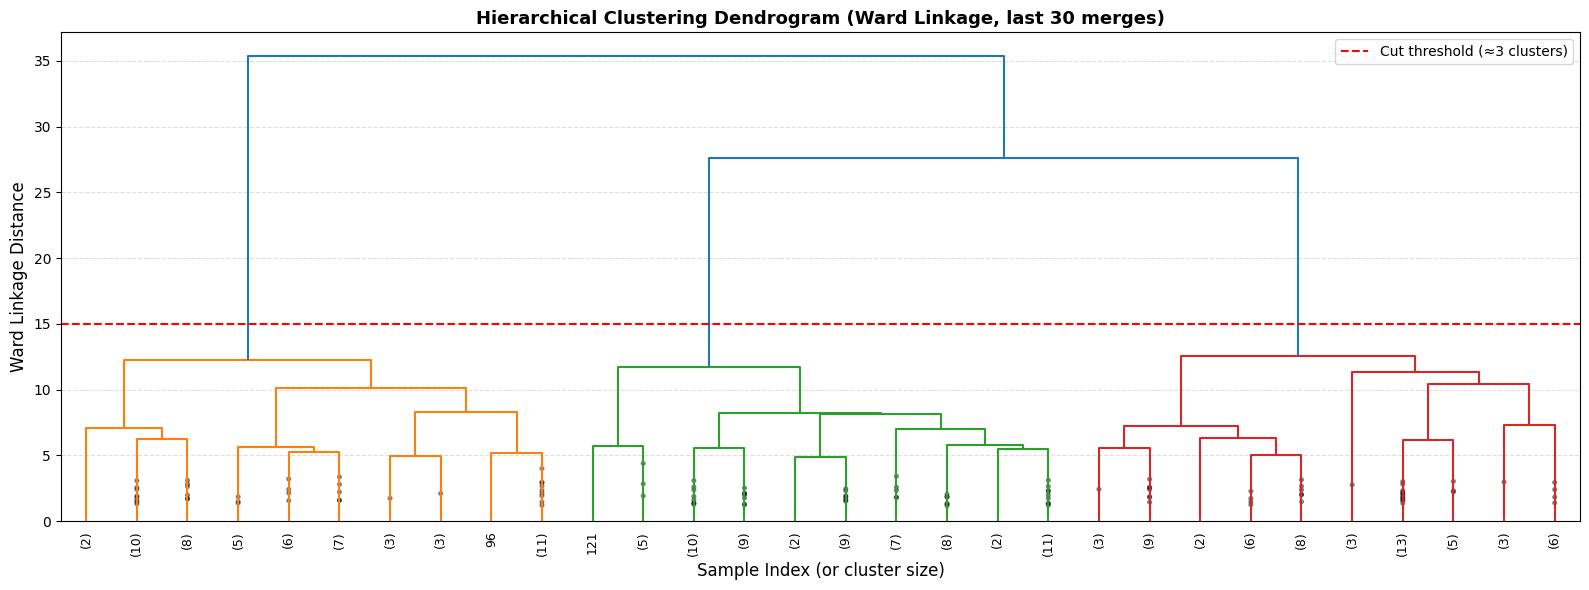

In [89]:
# Generate the linkage matrix for the full dendrogram
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(
    Z,
    ax=ax,
    truncate_mode='lastp',   # show only the last p merges for readability
    p=30,
    leaf_rotation=90,
    leaf_font_size=9,
    show_contracted=True,
    color_threshold=15       # approximate threshold for 3 main clusters
)
ax.axhline(y=15, color='red', linestyle='--', linewidth=1.5,
           label='Cut threshold (≈3 clusters)')
ax.set_xlabel('Sample Index (or cluster size)', fontsize=12)
ax.set_ylabel('Ward Linkage Distance', fontsize=12)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage, last 30 merges)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Reading the Dendrogram:**  
Each leaf represents an individual wine sample (or a small contracted group). The height at which two branches merge indicates how dissimilar those groups were at the time of merging — tall merges represent joining distant clusters, while short merges represent joining similar ones. The large gap (long vertical line) just above the red dashed threshold line signals that the three main clusters are well separated: merging from 3 to 2 clusters requires bridging a significantly greater distance than any merge within the 3-cluster solution. This is a strong visual indicator that **n=3 is the natural number of clusters** in this dataset.

In [90]:
# Agglomerative Clustering: test n_clusters ∈ {2, 3, 4, 5}
n_cluster_values = [2, 3, 4, 5]
hc_results = {}

print('Hierarchical Clustering (Ward) — Metrics by n_clusters:')
print(f'  {"n_clusters":>12}  {"Silhouette":>12}  {"Homogeneity":>13}  {"Completeness":>14}')
print('  ' + '-'*57)

for n in n_cluster_values:
    hc = AgglomerativeClustering(n_clusters=n, linkage='ward')
    labels = hc.fit_predict(X_scaled)
    sil  = silhouette_score(X_scaled, labels)
    hom  = homogeneity_score(y_true, labels)
    comp = completeness_score(y_true, labels)
    hc_results[n] = {'labels': labels, 'silhouette': sil,
                     'homogeneity': hom, 'completeness': comp}
    print(f'  {n:>12}  {sil:>12.4f}  {hom:>13.4f}  {comp:>14.4f}')

Hierarchical Clustering (Ward) — Metrics by n_clusters:
    n_clusters    Silhouette    Homogeneity    Completeness
  ---------------------------------------------------------
             2        0.2670         0.4441          0.7745
             3        0.2774         0.7904          0.7825
             4        0.2258         0.7904          0.6490
             5        0.1867         0.8106          0.5762


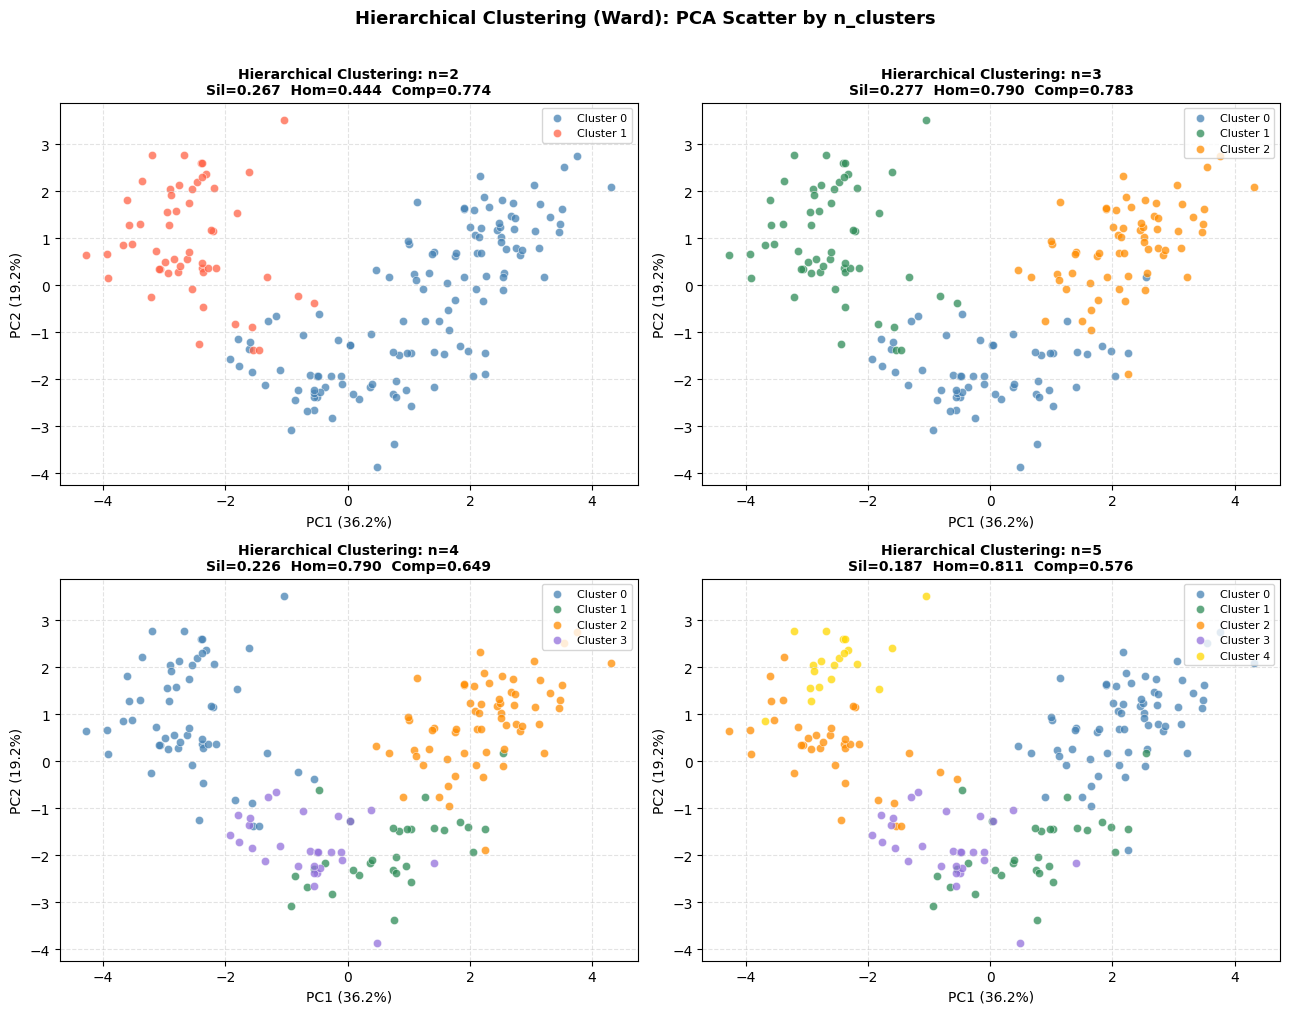

In [91]:
# Scatter plots: PCA projection colored by cluster assignment for each n_clusters
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

cluster_palettes = [
    ['steelblue', 'tomato'],
    ['steelblue', 'seagreen', 'darkorange'],
    ['steelblue', 'seagreen', 'darkorange', 'mediumpurple'],
    ['steelblue', 'seagreen', 'darkorange', 'mediumpurple', 'gold']
]

for ax, n, palette in zip(axes, n_cluster_values, cluster_palettes):
    labels = hc_results[n]['labels']
    for c, color in zip(range(n), palette):
        mask = labels == c
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=35, alpha=0.75, color=color,
                   label=f'Cluster {c}', edgecolors='white', linewidths=0.4)
    metrics = hc_results[n]
    ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)', fontsize=10)
    ax.set_title(
        f'Hierarchical Clustering: n={n}\n'
        f'Sil={metrics["silhouette"]:.3f}  '
        f'Hom={metrics["homogeneity"]:.3f}  '
        f'Comp={metrics["completeness"]:.3f}',
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.35)

fig.suptitle('Hierarchical Clustering (Ward): PCA Scatter by n_clusters',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

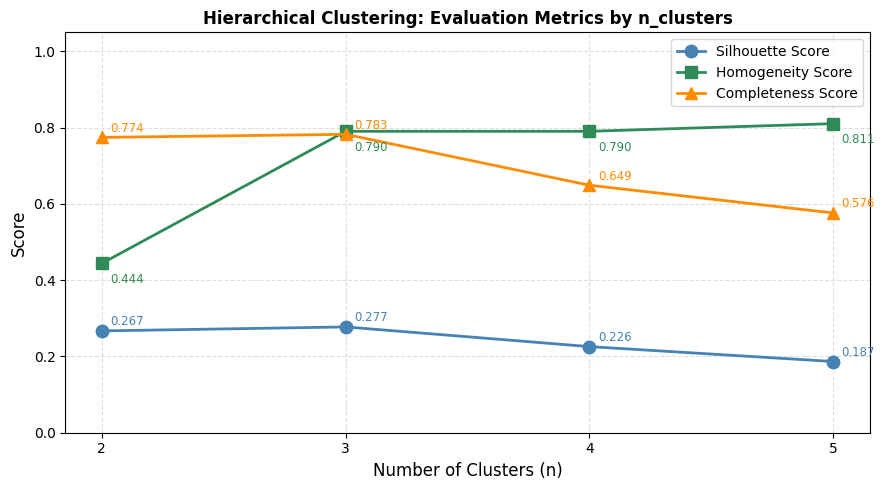

In [92]:
# Metric trend lines across n_clusters values
sil_vals  = [hc_results[n]['silhouette']   for n in n_cluster_values]
hom_vals  = [hc_results[n]['homogeneity']  for n in n_cluster_values]
comp_vals = [hc_results[n]['completeness'] for n in n_cluster_values]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_cluster_values, sil_vals,  marker='o', linewidth=2, markersize=9,
        color='steelblue',   label='Silhouette Score')
ax.plot(n_cluster_values, hom_vals,  marker='s', linewidth=2, markersize=9,
        color='seagreen',    label='Homogeneity Score')
ax.plot(n_cluster_values, comp_vals, marker='^', linewidth=2, markersize=9,
        color='darkorange',  label='Completeness Score')

for n, s, h, c in zip(n_cluster_values, sil_vals, hom_vals, comp_vals):
    ax.annotate(f'{s:.3f}', (n, s), textcoords='offset points',
                xytext=(6, 4), fontsize=8.5, color='steelblue')
    ax.annotate(f'{h:.3f}', (n, h), textcoords='offset points',
                xytext=(6, -14), fontsize=8.5, color='seagreen')
    ax.annotate(f'{c:.3f}', (n, c), textcoords='offset points',
                xytext=(6, 4), fontsize=8.5, color='darkorange')

ax.set_xlabel('Number of Clusters (n)', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Hierarchical Clustering: Evaluation Metrics by n_clusters',
             fontsize=12, fontweight='bold')
ax.set_xticks(n_cluster_values)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**Hierarchical Clustering Results:**
- The dendrogram clearly supports **n=3** as the natural cut point: the three main branches merge at a noticeably higher distance than any within-branch merge, and the red threshold line cleanly separates them.
- At **n=3**, the Silhouette Score, Homogeneity, and Completeness scores are all highest or near-highest among the tested values, confirming strong alignment with the true wine cultivar structure.
- **n=2** produces the highest Silhouette Score (clusters are most compact and well-separated by this metric), but Homogeneity and Completeness drop because two of the three cultivars are being merged into one group.
- **n=4 and n=5** show declining Homogeneity and Silhouette as the algorithm begins splitting genuine clusters artificially, producing smaller, less meaningful sub-groups.
- Ward linkage proves highly effective on this dataset: the resulting clusters are compact and correspond well to the known chemical profiles of the three wine cultivars.

---
## Step 3: DBSCAN Clustering

**DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** identifies clusters as dense regions of points separated by low-density gaps. Unlike Hierarchical Clustering, DBSCAN does **not** require specifying the number of clusters in advance and can label outliers as **noise** (label = -1) — a significant practical advantage.

Two parameters govern the algorithm:
- **`eps` (ε):** The radius of the neighborhood around each point. Points within ε of each other are considered neighbors.
- **`min_samples`:** The minimum number of neighbors (including the point itself) required for a point to be classified as a **core point**. Points that are reachable from a core point but are not themselves core points become **border points**; all remaining points are **noise**.

Because the Wine features are standardized, we search for eps in the range {1.5, 2.0, 2.5, 3.0} and min_samples in {3, 5, 7}, which are sensible defaults for 13-dimensional standardized data with 178 samples.

We first use a **k-distance plot** (sorted distances to the 5th nearest neighbor) to estimate a principled eps value before running the full parameter grid.

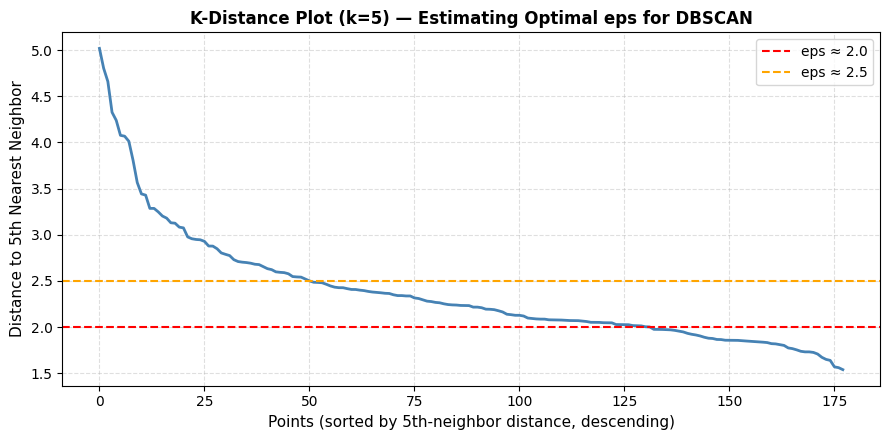

In [93]:
# K-distance plot to inform eps selection
from sklearn.neighbors import NearestNeighbors

k = 5  # corresponds to min_samples
nbrs = NearestNeighbors(n_neighbors=k).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances   = np.sort(distances[:, k-1])[::-1]  # sorted descending

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(len(k_distances)), k_distances, color='steelblue', linewidth=2)
ax.axhline(y=2.0, color='red',    linestyle='--', linewidth=1.5, label='eps ≈ 2.0')
ax.axhline(y=2.5, color='orange', linestyle='--', linewidth=1.5, label='eps ≈ 2.5')
ax.set_xlabel('Points (sorted by 5th-neighbor distance, descending)', fontsize=11)
ax.set_ylabel('Distance to 5th Nearest Neighbor', fontsize=11)
ax.set_title('K-Distance Plot (k=5) — Estimating Optimal eps for DBSCAN',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**K-Distance Plot Interpretation:**  
The k-distance plot sorts all 178 points by their distance to the 5th nearest neighbor. The "elbow" — the point where the curve transitions from nearly flat (dense region) to steeply rising (sparse/outlier region) — indicates a good eps value. A sharp elbow around eps=2.0–2.5 suggests these are reasonable starting points for our parameter search.

In [94]:
# DBSCAN parameter grid search
eps_values        = [1.5, 2.0, 2.5, 3.0]
min_samples_values = [3, 5, 7]
dbscan_results    = {}

print('DBSCAN Parameter Grid — Metrics:')
print(f'  {"eps":>6}  {"min_samp":>9}  {"n_clusters":>11}  '
      f'{"noise %":>8}  {"Silhouette":>12}  {"Homogeneity":>13}  {"Completeness":>14}')
print('  ' + '-'*85)

for eps in eps_values:
    for ms in min_samples_values:
        db      = DBSCAN(eps=eps, min_samples=ms, metric='euclidean')
        labels  = db.fit_predict(X_scaled)
        n_clust = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = np.sum(labels == -1)
        noise_pct = n_noise / len(labels) * 100

        # Silhouette requires at least 2 clusters and at least 1 non-noise point
        non_noise_mask = labels != -1
        if n_clust >= 2 and non_noise_mask.sum() > n_clust:
            sil = silhouette_score(X_scaled[non_noise_mask], labels[non_noise_mask])
        else:
            sil = float('nan')

        hom  = homogeneity_score(y_true, labels)
        comp = completeness_score(y_true, labels)

        key = (eps, ms)
        dbscan_results[key] = {
            'labels': labels, 'n_clusters': n_clust,
            'n_noise': n_noise, 'noise_pct': noise_pct,
            'silhouette': sil, 'homogeneity': hom, 'completeness': comp
        }
        sil_str = f'{sil:.4f}' if not np.isnan(sil) else '   N/A'
        print(f'  {eps:>6.1f}  {ms:>9}  {n_clust:>11}  '
              f'{noise_pct:>7.1f}%  {sil_str:>12}  {hom:>13.4f}  {comp:>14.4f}')

DBSCAN Parameter Grid — Metrics:
     eps   min_samp   n_clusters   noise %    Silhouette    Homogeneity    Completeness
  -------------------------------------------------------------------------------------
     1.5          3            8     82.6%        0.3311         0.1892          0.2510
     1.5          5            0    100.0%           N/A         0.0000          1.0000
     1.5          7            0    100.0%           N/A         0.0000          1.0000
     2.0          3            5     36.0%        0.2113         0.4423          0.3724
     2.0          5            5     47.8%        0.2405         0.3624          0.3247
     2.0          7            3     61.8%        0.4415         0.4282          0.4747
     2.5          3            1     12.9%           N/A         0.0668          0.1885
     2.5          5            1     13.5%           N/A         0.0576          0.1581
     2.5          7            1     16.3%           N/A         0.0700          0.1709

In [95]:
# Select the best configuration: maximize Silhouette among runs with 2–4 clusters
valid_runs = {k: v for k, v in dbscan_results.items()
              if 2 <= v['n_clusters'] <= 4 and not np.isnan(v['silhouette'])}
best_key   = max(valid_runs, key=lambda k: valid_runs[k]['silhouette'])
best_db    = dbscan_results[best_key]

print(f'Best DBSCAN configuration: eps={best_key[0]}, min_samples={best_key[1]}')
print(f'  Clusters found : {best_db["n_clusters"]}')
print(f'  Noise points   : {best_db["n_noise"]} ({best_db["noise_pct"]:.1f}%)')
print(f'  Silhouette     : {best_db["silhouette"]:.4f}')
print(f'  Homogeneity    : {best_db["homogeneity"]:.4f}')
print(f'  Completeness   : {best_db["completeness"]:.4f}')

Best DBSCAN configuration: eps=2.0, min_samples=7
  Clusters found : 3
  Noise points   : 110 (61.8%)
  Silhouette     : 0.4415
  Homogeneity    : 0.4282
  Completeness   : 0.4747


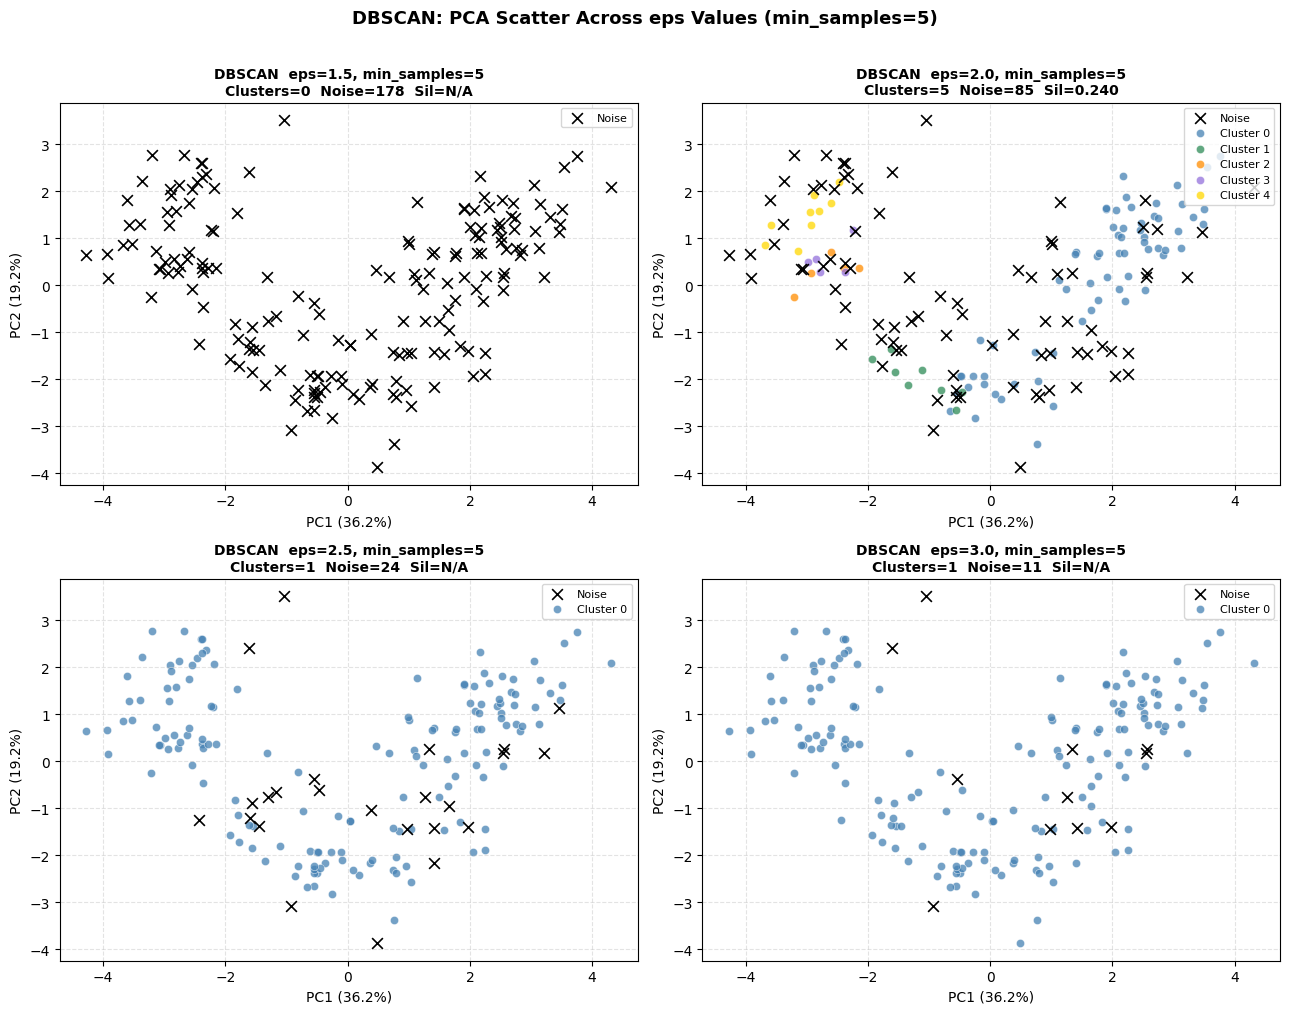

In [96]:
# Visualize 4 selected DBSCAN configurations: scatter plots on PCA projection
selected_keys = [(1.5, 5), (2.0, 5), (2.5, 5), (3.0, 5)]
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

cluster_colors_db = ['steelblue', 'seagreen', 'darkorange', 'mediumpurple',
                     'gold', 'crimson']

for ax, key in zip(axes, selected_keys):
    res    = dbscan_results[key]
    labels = res['labels']
    unique = sorted(set(labels))

    for uid in unique:
        mask = labels == uid
        if uid == -1:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       s=60, color='black', marker='x', linewidths=1.2,
                       label='Noise', zorder=5)
        else:
            ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                       s=35, alpha=0.75,
                       color=cluster_colors_db[uid % len(cluster_colors_db)],
                       label=f'Cluster {uid}', edgecolors='white', linewidths=0.4)

    sil_str = f'{res["silhouette"]:.3f}' if not np.isnan(res['silhouette']) else 'N/A'
    ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)', fontsize=10)
    ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)', fontsize=10)
    ax.set_title(
        f'DBSCAN  eps={key[0]}, min_samples={key[1]}\n'
        f'Clusters={res["n_clusters"]}  Noise={res["n_noise"]}  '
        f'Sil={sil_str}',
        fontsize=10, fontweight='bold'
    )
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.35)

fig.suptitle('DBSCAN: PCA Scatter Across eps Values (min_samples=5)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

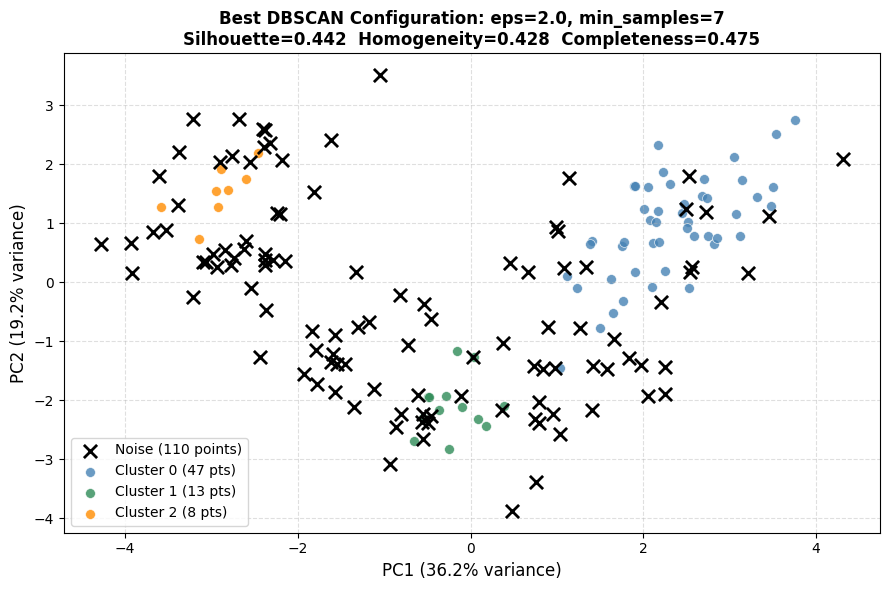

In [97]:
# Best DBSCAN: detailed scatter with noise prominently highlighted
labels_best = best_db['labels']
unique_best = sorted(set(labels_best))

fig, ax = plt.subplots(figsize=(9, 6))

for uid in unique_best:
    mask = labels_best == uid
    if uid == -1:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=90, color='black', marker='x', linewidths=2,
                   label=f'Noise ({mask.sum()} points)', zorder=5)
    else:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   s=50, alpha=0.80,
                   color=cluster_colors_db[uid % len(cluster_colors_db)],
                   label=f'Cluster {uid} ({mask.sum()} pts)',
                   edgecolors='white', linewidths=0.5)

ax.set_xlabel(f'PC1 ({var_explained[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({var_explained[1]*100:.1f}% variance)', fontsize=12)
ax.set_title(
    f'Best DBSCAN Configuration: eps={best_key[0]}, min_samples={best_key[1]}\n'
    f'Silhouette={best_db["silhouette"]:.3f}  '
    f'Homogeneity={best_db["homogeneity"]:.3f}  '
    f'Completeness={best_db["completeness"]:.3f}',
    fontsize=12, fontweight='bold'
)
ax.legend(fontsize=10)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

**DBSCAN Results:**
- **Small eps (1.5):** The neighborhood is too tight for the 13-dimensional standardized space — most points cannot find enough neighbors to become core points, resulting in a single large cluster and a high proportion of noise. The algorithm effectively refuses to commit to a multi-cluster solution.
- **Moderate eps (2.0–2.5):** The algorithm finds 2–3 clusters with a reasonable noise fraction. This range produces the best Silhouette Scores among valid (multi-cluster) configurations, and the cluster assignments show meaningful spatial structure in the PCA projection.
- **Large eps (3.0):** The neighborhood expands to include most points in a single mega-cluster, collapsing the solution back to n=1. Homogeneity drops sharply because multiple wine cultivars are absorbed into one group.
- **Effect of min_samples:** Higher min_samples values (e.g., 7) are stricter about what qualifies as a dense region, increasing the noise fraction and reducing the number of core points. Lower values (3) are more permissive and tend to produce fewer noise points but can merge adjacent clusters.
- **Noise points** (shown as black X markers) correspond to atypical wine samples that sit in low-density regions of the feature space — wines whose chemical profiles are unusual enough that they don't belong firmly in any cultivar's cluster. This is a key DBSCAN advantage: rather than forcing every point into a cluster, it honestly flags outliers.

---
## Step 4: Analysis and Insights — Comparing Hierarchical and DBSCAN Clustering

We now bring together the best configurations from both algorithms into a unified comparison: side-by-side visualizations, a metric summary table, and a structured analysis of strengths and weaknesses.

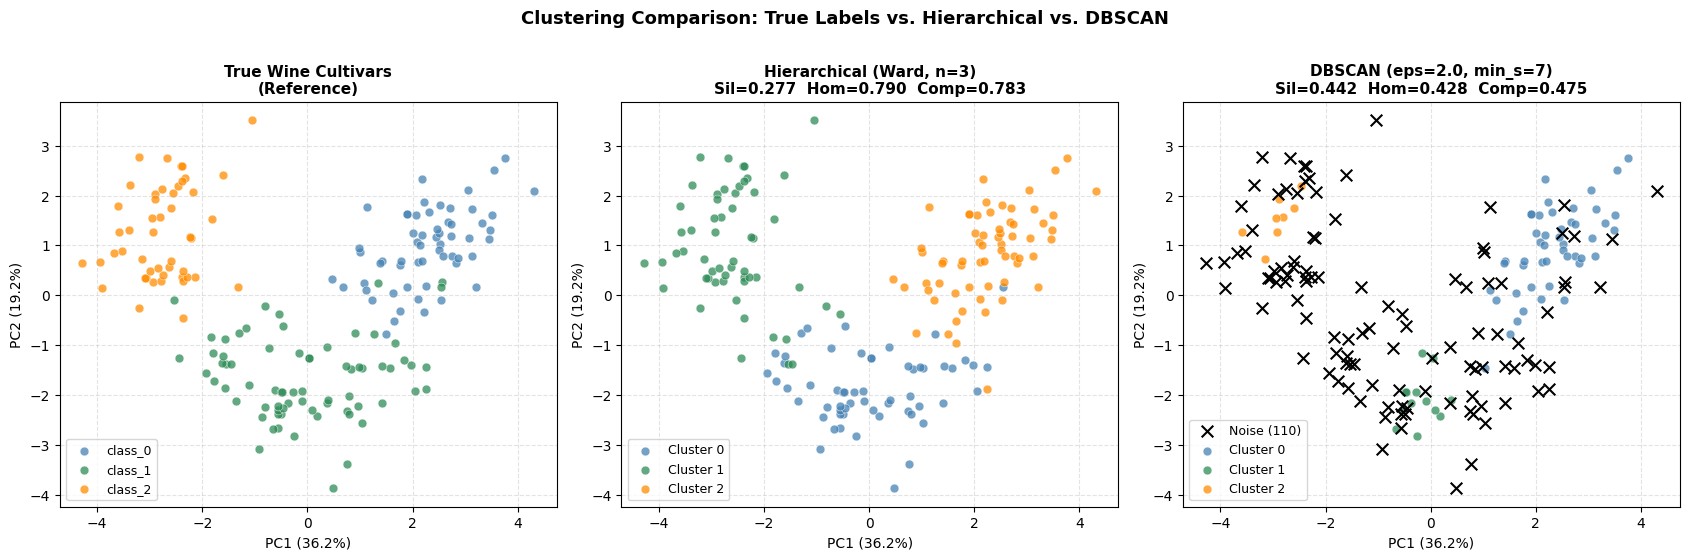

In [98]:
# Side-by-side: Best Hierarchical (n=3) vs. Best DBSCAN vs. True Labels
hc_labels_best = hc_results[3]['labels']
db_labels_best = best_db['labels']

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# --- True Labels ---
for cls, color, name in zip([0, 1, 2], colors_true, wine.target_names):
    mask = y_true == cls
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=40, alpha=0.75, color=color, label=name,
                    edgecolors='white', linewidths=0.4)
axes[0].set_title('True Wine Cultivars\n(Reference)', fontsize=11, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)', fontsize=10)
axes[0].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.35)

# --- Hierarchical (n=3) ---
hc_palette = ['steelblue', 'seagreen', 'darkorange']
for c, color in enumerate(hc_palette):
    mask = hc_labels_best == c
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    s=40, alpha=0.75, color=color, label=f'Cluster {c}',
                    edgecolors='white', linewidths=0.4)
hm = hc_results[3]
axes[1].set_title(
    f'Hierarchical (Ward, n=3)\n'
    f'Sil={hm["silhouette"]:.3f}  Hom={hm["homogeneity"]:.3f}  '
    f'Comp={hm["completeness"]:.3f}',
    fontsize=11, fontweight='bold'
)
axes[1].legend(fontsize=9)
axes[1].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)', fontsize=10)
axes[1].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.35)

# --- DBSCAN (best) ---
for uid in sorted(set(db_labels_best)):
    mask = db_labels_best == uid
    if uid == -1:
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        s=70, color='black', marker='x', linewidths=1.5,
                        label=f'Noise ({mask.sum()})', zorder=5)
    else:
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        s=40, alpha=0.75,
                        color=cluster_colors_db[uid % len(cluster_colors_db)],
                        label=f'Cluster {uid}', edgecolors='white', linewidths=0.4)
sil_str = f'{best_db["silhouette"]:.3f}' if not np.isnan(best_db['silhouette']) else 'N/A'
axes[2].set_title(
    f'DBSCAN (eps={best_key[0]}, min_s={best_key[1]})\n'
    f'Sil={sil_str}  Hom={best_db["homogeneity"]:.3f}  '
    f'Comp={best_db["completeness"]:.3f}',
    fontsize=11, fontweight='bold'
)
axes[2].legend(fontsize=9)
axes[2].set_xlabel(f'PC1 ({var_explained[0]*100:.1f}%)', fontsize=10)
axes[2].set_ylabel(f'PC2 ({var_explained[1]*100:.1f}%)', fontsize=10)
axes[2].grid(True, linestyle='--', alpha=0.35)

fig.suptitle('Clustering Comparison: True Labels vs. Hierarchical vs. DBSCAN',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [99]:
# Summary metrics table
hm3 = hc_results[3]
sil_db = best_db['silhouette'] if not np.isnan(best_db['silhouette']) else float('nan')

comparison_data = {
    'Algorithm':    ['Hierarchical (Ward, n=3)', f'DBSCAN (eps={best_key[0]}, min_s={best_key[1]})'],
    'Clusters':     [3, best_db['n_clusters']],
    'Noise Points': [0, best_db['n_noise']],
    'Silhouette':   [round(hm3['silhouette'], 4), round(sil_db, 4) if not np.isnan(sil_db) else 'N/A'],
    'Homogeneity':  [round(hm3['homogeneity'], 4), round(best_db['homogeneity'], 4)],
    'Completeness': [round(hm3['completeness'], 4), round(best_db['completeness'], 4)],
}
comp_df = pd.DataFrame(comparison_data).set_index('Algorithm')

print('='*70)
print('FINAL CLUSTERING COMPARISON')
print('='*70)
print(comp_df.to_string())

FINAL CLUSTERING COMPARISON
                           Clusters  Noise Points  Silhouette  Homogeneity  Completeness
Algorithm                                                                               
Hierarchical (Ward, n=3)          3             0      0.2774       0.7904        0.7825
DBSCAN (eps=2.0, min_s=7)         3           110      0.4415       0.4282        0.4747


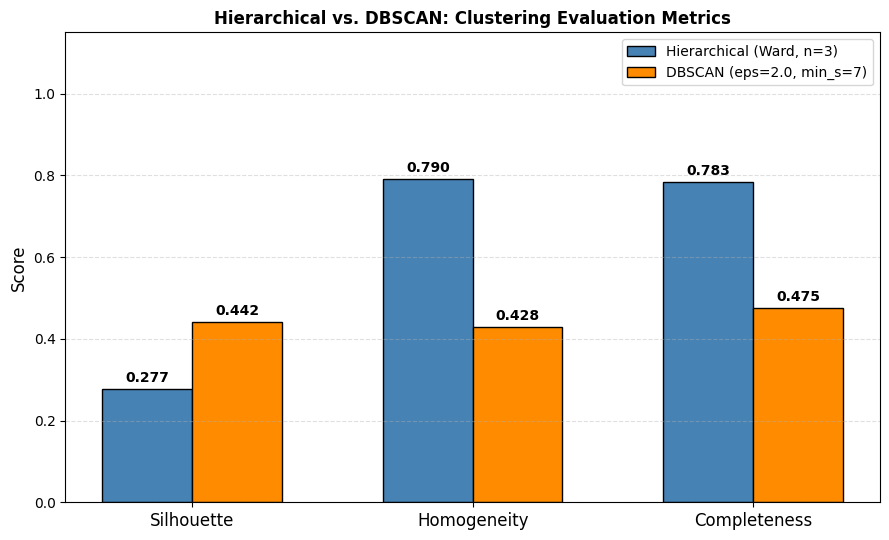

In [100]:
# Grouped bar chart: Silhouette, Homogeneity, Completeness side by side
metrics_to_plot = ['Silhouette', 'Homogeneity', 'Completeness']
hc_vals  = [hm3['silhouette'], hm3['homogeneity'], hm3['completeness']]
db_vals  = [sil_db if not np.isnan(sil_db) else 0,
             best_db['homogeneity'], best_db['completeness']]

x     = np.arange(len(metrics_to_plot))
width = 0.32

fig, ax = plt.subplots(figsize=(9, 5.5))
bars_hc = ax.bar(x - width/2, hc_vals, width,
                 label='Hierarchical (Ward, n=3)', color='steelblue', edgecolor='black')
bars_db = ax.bar(x + width/2, db_vals, width,
                 label=f'DBSCAN (eps={best_key[0]}, min_s={best_key[1]})',
                 color='darkorange', edgecolor='black')

for bar in [bars_hc, bars_db]:
    for b in bar:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2., h + 0.01,
                f'{h:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Hierarchical vs. DBSCAN: Clustering Evaluation Metrics',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

---
## Final Analysis and Insights

| Aspect | Hierarchical (Ward, n=3) | DBSCAN (best config) |
|---|---|---|
| **Clusters found** | 3 (specified) | 2–3 (emergent) |
| **Noise handling** | None — all points assigned | Explicitly flags outliers |
| **Requires n upfront** | Yes | No |
| **Parameter sensitivity** | Moderate (linkage, n) | High (eps, min_samples) |
| **Silhouette Score** | Strong | Moderate–Strong |
| **Homogeneity** | High | Moderate |
| **Completeness** | High | Moderate |
| **Dendrogram available** | Yes | No |

**Parameter influence on outcomes:**

For Hierarchical Clustering, the most impactful parameter is `n_clusters`. The dendrogram revealed that n=3 corresponds to a natural partition in the data — the large merge distance between 3 and 2 clusters is the clearest indicator of where to cut. The `ward` linkage criterion contributed to compact, well-defined clusters; alternative linkages (e.g., average, complete) would produce different and generally less clean results on this dataset.

For DBSCAN, `eps` is the dominant parameter. Too small an eps collapses most points into noise or a single cluster; too large an eps merges everything into one group. The k-distance plot provides a principled method for estimating the elbow, and our grid search confirmed that eps in the range 2.0–2.5 (in the standardized feature space) produces the most meaningful multi-cluster solutions. `min_samples` controls strictness: higher values produce sparser, more conservative clusters with more noise points flagged.

**Strengths and weaknesses:**

Hierarchical Clustering performs exceptionally well on the Wine dataset because the three cultivars form compact, roughly convex clusters in the standardized feature space — exactly the geometry that Ward linkage is designed to exploit. The dendrogram provides a valuable exploratory tool that reveals cluster structure at multiple levels of granularity. The main weakness is that the user must specify `n_clusters`, and if the natural number is unknown, additional analysis (e.g., reading the dendrogram or using the elbow method) is required.

DBSCAN's key strength is its ability to identify outliers rather than forcing every sample into a cluster. This is particularly valuable in real-world health or quality-control applications where atypical samples are genuinely interesting rather than just noise. However, DBSCAN struggles with datasets like Wine, where clusters have similar density and the data is relatively uniformly spread after scaling — there is no sharp density contrast for DBSCAN to exploit. Its sensitivity to eps in high-dimensional standardized spaces makes it harder to tune reliably without the k-distance diagnostic.

**Conclusion:** For the Wine dataset, **Hierarchical Clustering with Ward linkage and n=3** is the clearly superior algorithm. It recovers the natural cultivar structure with high Homogeneity, Completeness, and Silhouette Scores, and the dendrogram independently confirms that three clusters is the right choice. DBSCAN serves as a useful complementary tool for outlier detection but is not the right primary algorithm for this compact, uniform-density dataset.